# Content Analysis
Analyzing the versions in `data/dataset`.

In [20]:
import pandas as pd

selected = pd.read_json(
    "data/dataset/selected_versions.json", orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )
    
selected_filtered = pd.read_json(
    "data/dataset/selected_versions_filtered.json", orient='index'
    ).explode("youtube_id").reset_index().rename(
        columns={'index': 'clique_id'}
        )


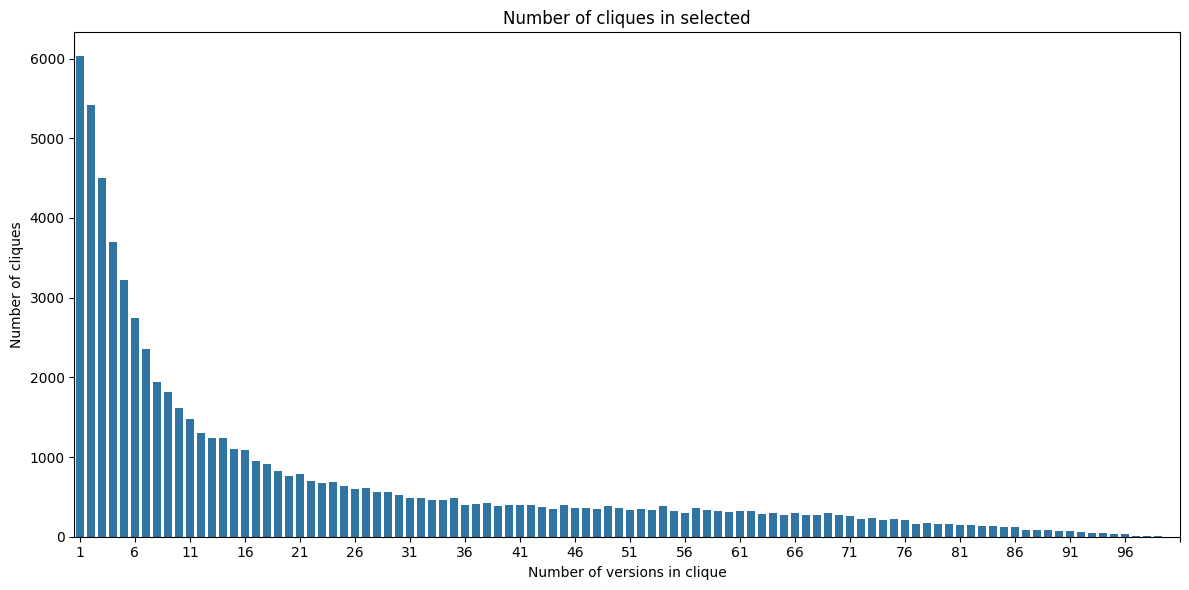

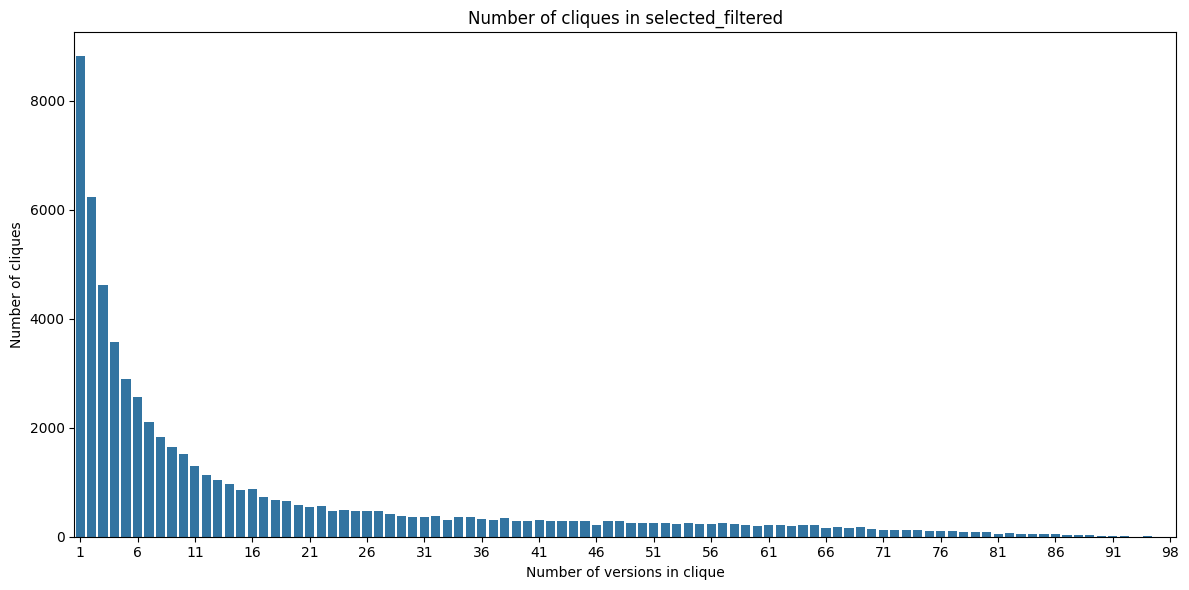

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_clique_size_distribution(selected, dataset_name):
    """
    Plots the distribution of clique sizes from the `selected` dictionary or DataFrame.

    Args:
        selected (dict or DataFrame): Must contain 'clique_id' repeated per YouTube ID.
        title (str): Title of the plot.

    Returns:
        None
    """
    # Compute distribution
    clique_sizes = selected['clique_id'].value_counts()
    size_distribution = clique_sizes.value_counts().sort_index()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=size_distribution.index, y=size_distribution.values)

    plt.xticks(ticks=range(0, max(size_distribution.index)+1, 5))
    plt.title('Number of cliques in ' + dataset_name)
    plt.xlabel('Number of versions in clique')
    plt.ylabel('Number of cliques')
    plt.tight_layout()
    plt.show()

plot_clique_size_distribution(selected, "selected")
plot_clique_size_distribution(selected_filtered, "selected_filtered")


In [22]:
metadata = pd.read_json("data/metadata_filtered.jsonl", lines=True, orient='records')
metadata = metadata.loc[metadata.id.isin(selected.youtube_id),:]

new_columns = ["clique_id"] + metadata.columns.tolist()
metadata = pd.merge(
    selected.reset_index(),
    metadata,
    left_on="youtube_id",
    right_on="id",
    how="left",
)
metadata = metadata[new_columns]


In [23]:
def time_to_seconds(time_str):
    parts = list(map(int, time_str.split(":")))
    if len(parts) == 3:  # HH:MM:SS
        h, m, s = parts
        return h * 3600 + m * 60 + s
    elif len(parts) == 2:  # MM:SS
        m, s = parts
        return m * 60 + s
    elif len(parts) == 1:  # SS
        return parts[0]
    else:
        raise ValueError(f"Unrecognized time format: {time_str}")
    
metadata["duration_secs"] = metadata["duration"].apply(time_to_seconds)
metadata["duration_mins"] = metadata["duration_secs"] / 60


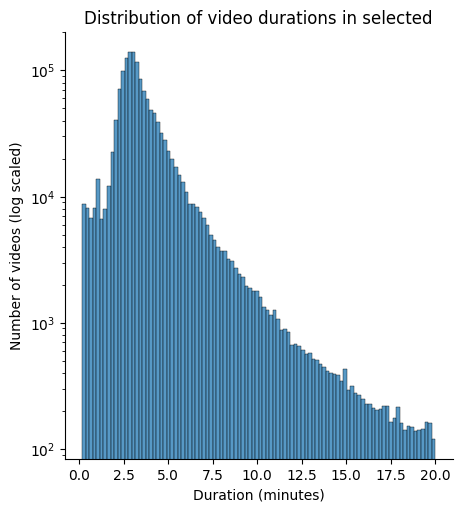

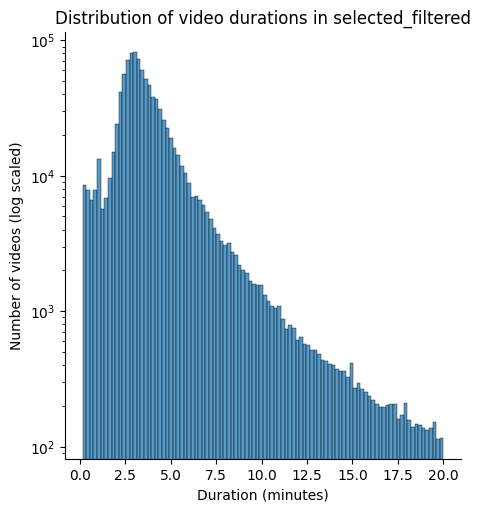

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_duration_distribution(metadata, dataset_name, bins=100):
    sns.displot(metadata, x="duration_mins", bins=bins)
    plt.xlabel("Duration (minutes)")
    plt.ylabel("Number of videos (log scaled)")
    plt.yscale('log')  # <-- set y-axis to log scale
    plt.title('Distribution of video durations in ' + dataset_name)
    plt.show()

plot_duration_distribution(metadata, dataset_name="selected")
plot_duration_distribution(metadata.loc[metadata.id.isin(selected_filtered.youtube_id)], 
                           dataset_name="selected_filtered")


In [28]:
def get_description_str(descriptionSnippet):
    if isinstance(descriptionSnippet, list):
        return " ".join([d["text"] for d in descriptionSnippet]).replace("\n", " ").replace("\r", " ")
    else:
        return descriptionSnippet

metadata["description"] = metadata.descriptionSnippet.apply(get_description_str)


In [12]:
from collections import Counter
from itertools import islice
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Make sure you've downloaded stopwords & tokenizer models:
# import nltk
# nltk.download('punkt')
# nltk.download('stopwords')

# Combine stopwords from multiple languages
languages = ['english', 'german', 'french', 'spanish', 'italian', 'portuguese']  # extend as needed
stop_words = set()
for lang in languages:
    stop_words.update(stopwords.words(lang))

def ngrams(tokens, n):
    return zip(*(islice(tokens, i, None) for i in range(n)))

def clean_and_tokenize(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalnum() and word not in stop_words]

def get_top_ngrams(series, n=1, top_k=20):
    all_ngrams = Counter()
    for text in series.dropna().astype(str):
        tokens = clean_and_tokenize(text)
        all_ngrams.update(ngrams(tokens, n))
    return all_ngrams.most_common(top_k)

# Assuming your dataframe is called df
for column in ['title', 'description']:
    print(f"\n==== {column.upper()} ====")
    for n in [1, 2, 3]:
        top = get_top_ngrams(metadata[column], n=n, top_k=15)  # adjust top_k as needed
        print(f"\nTop {n}-grams (stopwords removed):")
        for phrase, count in top:
            joined = " ".join(phrase) if isinstance(phrase, tuple) else phrase
            print(f"{joined}: {count}")



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 75015
live: 72398
love: 56999
blues: 46457
remastered: 32118
version: 29528
lyrics: 27755
karaoke: 23889
guitar: 21916
little: 20092
video: 18144
time: 17712
baby: 17539
heart: 15280
music: 15280

Top 2-grams (stopwords removed):
karaoke version: 9419
elvis presley: 5063
official audio: 4919
guitar cover: 4880
first time: 4789
bob dylan: 4721
guitar lesson: 4314
music video: 4306
bass cover: 3774
taylor swift: 3659
official video: 3391
remastered 2014: 3290
time hearing: 3064
acoustic cover: 3024
drum cover: 2939

Top 3-grams (stopwords removed):
first time hearing: 3038
official music video: 2372
karaoke version karafun: 1388
karaoke version zoom: 1184
version zoom karaoke: 1169
nat king cole: 1029
first time reaction: 944
bob dylan cover: 892
townes van zandt: 840
version originally performed: 833
karaoke version originally: 826
guitar lesson tutorial: 826
jerry lee lewis: 817
creedence clearwater revival: 731
official lyric v

In [30]:
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from itertools import islice

# Ensure required NLTK resources are downloaded
nltk.download('punkt')
nltk.download('stopwords')

def analyze_top_ngrams(
    df,
    ngram_range=(1, 3),
    top_k=15,
    languages=('english', 'german', 'french', 'spanish', 'italian', 'portuguese')
):
    """
    Analyzes top n-grams in specified text columns of a DataFrame after cleaning and stopword removal.

    Args:
        df (pd.DataFrame): DataFrame containing text data.
        ngram_range (tuple): (min_n, max_n) tuple for n-gram lengths.
        top_k (int): Number of top n-grams to return.
        languages (tuple): Languages whose stopwords to combine.

    Returns:
        dict: Nested dictionary of top n-grams per column and n.
    """
    # Compile stopwords from multiple languages
    stop_words = set()
    for lang in languages:
        stop_words.update(stopwords.words(lang))

    def ngrams(tokens, n):
        return zip(*(islice(tokens, i, None) for i in range(n)))

    def clean_and_tokenize(text):
        tokens = word_tokenize(text.lower())
        return [word for word in tokens if word.isalnum() and word not in stop_words]

    results = {}

    text_columns = ['title', 'description']
    for column in text_columns:
        print(f"\n==== {column.upper()} ====")
        col_results = {}
        for n in range(ngram_range[0], ngram_range[1] + 1):
            all_ngrams = Counter()
            for text in df[column].dropna().astype(str):
                tokens = clean_and_tokenize(text)
                all_ngrams.update(ngrams(tokens, n))
            top = all_ngrams.most_common(top_k)

            print(f"\nTop {n}-grams (stopwords removed):")
            for phrase, count in top:
                joined = " ".join(phrase) if isinstance(phrase, tuple) else phrase
                print(f"{joined}: {count}")

            col_results[n] = top
        results[column] = col_results

    return results

results_metadata = analyze_top_ngrams(
    metadata,
    ngram_range=(1, 3),
    top_k=15
)



[nltk_data] Downloading package punkt to /home/azimuth/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azimuth/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 75157
live: 72791
love: 57315
blues: 46947
remastered: 32321
version: 29615
lyrics: 27862
karaoke: 23930
guitar: 21982
little: 20262
video: 18266
time: 17801
baby: 17728
music: 15365
heart: 15362

Top 2-grams (stopwords removed):
karaoke version: 9445
elvis presley: 5129
official audio: 4965
guitar cover: 4884
first time: 4796
bob dylan: 4739
music video: 4340
guitar lesson: 4331
bass cover: 3779
taylor swift: 3680
official video: 3426
remastered 2014: 3309
time hearing: 3067
acoustic cover: 3027
drum cover: 2943

Top 3-grams (stopwords removed):
first time hearing: 3041
official music video: 2402
karaoke version karafun: 1398
karaoke version zoom: 1189
version zoom karaoke: 1174
nat king cole: 1032
first time reaction: 946
bob dylan cover: 893
townes van zandt: 840
version originally performed: 833
guitar lesson tutorial: 829
jerry lee lewis: 828
karaoke version originally: 826
creedence clearwater revival: 731
official lyric v

In [31]:
results_metadata = analyze_top_ngrams(
    metadata.loc[metadata.id.isin(selected_filtered.youtube_id)],
    ngram_range=(1, 3),
    top_k=15
)



==== TITLE ====

Top 1-grams (stopwords removed):
cover: 74247
live: 64781
love: 41969
lyrics: 27500
blues: 23356
guitar: 21325
version: 21217
karaoke: 18369
time: 14372
john: 13507
little: 13361
band: 11623
baby: 11157
heart: 11127
song: 11021

Top 2-grams (stopwords removed):
karaoke version: 5344
guitar cover: 4882
first time: 4615
elvis presley: 4581
bob dylan: 4442
guitar lesson: 4329
bass cover: 3777
taylor swift: 3298
acoustic cover: 3017
time hearing: 2987
drum cover: 2938
rolling stones: 2569
hits archive: 2468
elton john: 2447
stevie wonder: 2176

Top 3-grams (stopwords removed):
first time hearing: 2961
karaoke version karafun: 1398
karaoke version zoom: 1189
version zoom karaoke: 1174
nat king cole: 994
first time reaction: 916
bob dylan cover: 885
guitar lesson tutorial: 829
jerry lee lewis: 806
townes van zandt: 742
creedence clearwater revival: 648
bass cover tabs: 636
gladys knight pips: 461
stevie ray vaughan: 430
pet shop boys: 419

==== DESCRIPTION ====

Top 1-grams